In [42]:
from ollama import chat
from ollama import ChatResponse
import secrets
from Crypto.Cipher import AES
from sklearn.cluster import SpectralClustering
from sklearn.model_selection import train_test_split
from Crypto.Cipher import AES
from Crypto.Hash import SHAKE128
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D, Attention, Normalization, Reshape, Conv2DTranspose, MultiHeadAttention
import polars as pl
import os
from Crypto.Util.Padding import pad, unpad
import math
from keras import Model, Input, Sequential
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
'''Passwords & Hashes'''
passwords = [b"Andromeda", b"Neptune", b"Jupiter", b"Saturn"]
algs= ['128', '256'] #be sure to add 512 eventually
hash128 = {password: SHAKE128.new(password).read(128 // 8) for password in passwords}
hash256 = {password: SHAKE128.new(password).read(256 // 8) for password in passwords}
hash512 = {password: SHAKE128.new(password).read(512 // 8) for password in passwords}
print(hash512[b'Andromeda'])
print(hash128)

b"p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^\x8c\xc3a\x93\xf2\xca\xc6\xafI\xaf\x93\x1f\xe6\x8d\x05)\xb5\xa1\x08\x86X\x02\xc9'\x07\x84\xf3bl\\\x99f"
{b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x86', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14'}


In [4]:
'''Encrypt Messages'''
'''need all ciphertexts to be the same size, maybe just set a block limit based on the shortest message length?'''
#should only need to be done once
def encryptMessages(size, pass_dict, max_blocks):
    max_bytes = max_blocks * 512 // 8 #should be a perfect division anyways
    passwords = list(pass_dict.keys())
    for (root, dirs, files) in os.walk("../HumanReadable"):
        for file in files:
            with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
                plaintext = plaintextstore.read()
                for password in passwords:
                    #print(len(pass_dict[password]))
                    with open(f'../{size}ciphertext/{size}_{password}_{file}', 'wb') as cipherstore:
                        ciphertext = AES.new(pass_dict[password], AES.MODE_ECB).encrypt(pad(plaintext[:max_bytes], 512, 'iso7816'))
                        cipherstore.write(ciphertext)
#not most blocks present but most blocks to use = num blocks in shortest message
max_blocks = 1000
image_shape = [8, 8]
for (root, dirs, files) in os.walk("../HumanReadable"):
    for file in files:
        with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
            plaintext = plaintextstore.read()
            if math.ceil((len(plaintext) * 8) / 512) < max_blocks:
                max_blocks = math.ceil((len(plaintext) * 8) / 512)
print(math.sqrt((512 * max_blocks) / 8))
img_size = (512 * max_blocks) / 8
s = math.floor(math.sqrt(img_size))
l = s
w = s
r = img_size - (l*w)
while r != 0:
    l -= 1
    w = math.floor(img_size / l)
    r = img_size - (l*w)
image_shape = [l,w]
image_shape.append(1)
image_shape = tuple(image_shape)
print(max_blocks, image_shape)
assert(image_shape[0] * image_shape[1] == (512 * max_blocks) / 8)
encryptMessages('128', hash128, max_blocks)
encryptMessages('256', hash256, max_blocks)

49.95998398718719
39 (48, 52, 1)


In [5]:
'''Compile Training Data'''
columns = ['alg', 'password', 'source_file', 'plaintext', 'ciphertext']
data = []
for alg in algs:
    for password in passwords:
        for (root, dirs, files) in os.walk("../HumanReadable"):
            for source_file in files:
                with open(f'../HumanReadable/{source_file}', 'rb') as plaintextstore:
                    plaintext = plaintextstore.read()
                    with open(f'../{alg}ciphertext/{alg}_{password}_{source_file}', 'rb') as cipherstore:
                        #If there is an error run encryption again
                        ciphertext = cipherstore.read()
                        #print(len(ciphertext))
                        #normalize and want (l,w,d) shape
                        ciphertextimage = [[[int(byte)/255] for byte in ciphertext[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                        ciphertextimagearray = np.asarray(ciphertextimage, np.float32)
                        data.append([alg, password, source_file, plaintext, ciphertextimagearray])

df = pl.LazyFrame(data, columns, orient='row')
df = df.collect()
df = df.sample(fraction=1, shuffle= True)
#df = df.to_dummies(columns[:-2])
train_size = math.floor( .9 * len(df))
test_size = len(df) - train_size
train, test = df.head(train_size), df.tail(test_size)
train_data, test_data = train['ciphertext'], test['ciphertext']
train_targets, test_targets = train.select(pl.exclude('ciphertext')), test.select(pl.exclude('ciphertext'))

In [6]:
train_data_format = np.array(train_data.to_list())
test_data_format = np.array(test_data.to_list())
sources = df['source_file'].unique()
print(sources)

shape: (200,)
Series: 'source_file' [str]
[
	"Convo24Message3"
	"Convo20Message2"
	"Convo27Message2"
	"Convo29Message0"
	"Convo1Message3"
	…
	"Convo5Message2"
	"Convo10Message0"
	"Convo33Message4"
	"Convo31Message0"
	"Convo32Message4"
]


In [7]:
def make_mapping(data, enum_vals, col_name):
    mapping = {enum_val: i for i, enum_val in enumerate(enum_vals)}
    mapped_data = data.with_columns(
    pl.col(col_name).replace_strict(mapping)
    )
    return mapped_data, mapping

In [8]:
print(train_targets.head())

shape: (5, 4)
┌─────┬──────────────┬─────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file     ┆ plaintext                       │
│ --- ┆ ---          ┆ ---             ┆ ---                             │
│ str ┆ binary       ┆ str             ┆ binary                          │
╞═════╪══════════════╪═════════════════╪═════════════════════════════════╡
│ 128 ┆ b"Andromeda" ┆ Convo23Message3 ┆ b"Subject:\x20Re:\x20Nightinga… │
│ 256 ┆ b"Jupiter"   ┆ Convo7Message3  ┆ b"Subject:\x20Re:\x20Blackbird… │
│ 128 ┆ b"Andromeda" ┆ Convo38Message4 ┆ b"Subject:\x20Re:\x20Crimson\x… │
│ 256 ┆ b"Neptune"   ┆ Convo16Message2 ┆ b"Subject:\x20Re:\x20Nightinga… │
│ 256 ┆ b"Jupiter"   ┆ Convo1Message4  ┆ b"Subject:\x20Re:\x20Nightinga… │
└─────┴──────────────┴─────────────────┴─────────────────────────────────┘


In [64]:
'''Autoencoder'''
#is mean pooling worth investigating
#will need to play around with amount of parameters
#should i include more than just the ciphertext?
encoder_input = Input(shape=image_shape)
#4x4 byte matrix is AES operator size seems fitting
#blocks*4 is the amount of AES-128 blocks which seems like a decent starting metric
encoder1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')(encoder_input)
encoder2 = MaxPool2D(pool_size=(4,4), strides=4)(encoder1)
encoder3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')(encoder2)
encoder4 = MaxPool2D(pool_size=(2,2), strides=4)(encoder3)
encoder5 = Flatten()(encoder4)
embedded_layer = Dense(3, activation='relu')(encoder5)
decoder1 = Dense(4, activation='relu')(embedded_layer)
decoder2 = Reshape((2,2,1))(decoder1)
decoder3 = Conv2DTranspose(max_blocks, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
#decoder3 = Conv2DTranspose(max_blocks * 4, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
decoder4 = Conv2D(1, (4, 4), activation="sigmoid", padding="same")(decoder3)

autoencoder = Model(encoder_input, decoder4)
encoder = Model(encoder_input, embedded_layer)


In [65]:
autoencoder.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 48, 52, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 48, 52, 156)    │         2,652 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 12, 13, 156)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 12, 13, 39)     │        97,383 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 3, 3, 39)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 351)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_16 (Reshape)            │ (None, 2, 2, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 48, 52, 39)     │           195 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 48, 52, 1)      │           625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,927 (398.15 KB)

 Trainable params: 101,927 (398.15 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
'''keras example uses binary_crossentropy but they also had binary images, description says its for binary classification though'''
autoencoder.compile(optimizer="adam", loss="mse")
history = autoencoder.fit(train_data_format, train_data_format, epochs = 200)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0839
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0840
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0840
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0839
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0839
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 13/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0840
Epoch 14/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoch 15/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0839
Epoc

In [12]:
encode = encoder.predict(test_data_format)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [13]:
len(train_data.to_list())

1440

In [36]:
'''Supervised Classification'''
activation = ''
if len(algs) == 2:
    activation = 'sigmoid'
else:
    activation = 'softmax'
# encoder_input = Input(shape=image_shape)
# algclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
# alg_drop1 = Dropout(.3)
# algclass2 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
# alg_drop2 = Dropout(.3)
# algclass4 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass5 = Flatten()
# alg_prediction_layer = Dense(len(algs), activation=activation)
# alg_classifier = Sequential([encoder_input, algclass1, alg_drop1, algclass2, algclass3, alg_drop2, algclass4, algclass5, alg_prediction_layer])
pass_heads = 4
pass_key_dim =16
alg_atten_dim = pass_heads*pass_key_dim
alg_input = Input(shape=image_shape)
alg_classifier = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')(alg_input)
alg_classifier = Dropout(.3)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=4)(alg_classifier)
alg_classifier = Conv2D(max_blocks, (4,4), padding='same', activation='relu')(alg_classifier)
alg_classifier = Dropout(.3)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=4)(alg_classifier)
alg_classifier = Conv2D(alg_atten_dim, kernel_size=1)(alg_classifier)
alg_classifier = Reshape((-1, alg_atten_dim))(alg_classifier)
alg_classifier = MultiHeadAttention(num_heads=pass_heads, key_dim=pass_key_dim)(alg_classifier, alg_classifier)
alg_classifier = Flatten()(alg_classifier)
alg_classifier = Dense(len(algs), activation=activation)(alg_classifier)
alg_classifier = Model(alg_input, alg_classifier)

In [37]:
alg_classifier.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 48, 52, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 48, 52,    │      2,652 │ input_layer_7[0]… │
│                     │ 156)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 48, 52,    │          0 │ conv2d_20[0][0]   │
│ (Dropout)           │ 156)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 12, 13,    │          0 │ dropout_15[0][0]  │
│ (MaxPooling2D)      │ 156)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 12, 13,    │     97,383 │ max_pooling2d_14… │
│                     │ 39)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 12, 13,    │          0 │ conv2d_21[0][0]   │
│ (Dropout)           │ 39)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 3, 3, 39)  │          0 │ dropout_16[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 3, 3, 64)  │      2,560 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 9, 64)     │          0 │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 64)     │     16,640 │ reshape_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 576)       │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2)         │      1,154 │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,389 (470.27 KB)

 Trainable params: 120,389 (470.27 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [38]:
#use sparse categorical entropy for loss function i think
#may need to resize?
enum_alg_targets, alg_mapping = make_mapping(train_targets, algs, 'alg')
print(enum_alg_targets)
alg_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
alg_hist = alg_classifier.fit(train_data_format, enum_alg_targets['alg'].to_numpy(), epochs=200)

shape: (1_440, 4)
┌─────┬──────────────┬─────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file     ┆ plaintext                       │
│ --- ┆ ---          ┆ ---             ┆ ---                             │
│ i64 ┆ binary       ┆ str             ┆ binary                          │
╞═════╪══════════════╪═════════════════╪═════════════════════════════════╡
│ 0   ┆ b"Andromeda" ┆ Convo23Message3 ┆ b"Subject:\x20Re:\x20Nightinga… │
│ 1   ┆ b"Jupiter"   ┆ Convo7Message3  ┆ b"Subject:\x20Re:\x20Blackbird… │
│ 0   ┆ b"Andromeda" ┆ Convo38Message4 ┆ b"Subject:\x20Re:\x20Crimson\x… │
│ 1   ┆ b"Neptune"   ┆ Convo16Message2 ┆ b"Subject:\x20Re:\x20Nightinga… │
│ 1   ┆ b"Jupiter"   ┆ Convo1Message4  ┆ b"Subject:\x20Re:\x20Nightinga… │
│ …   ┆ …            ┆ …               ┆ …                               │
│ 0   ┆ b"Jupiter"   ┆ Convo20Message4 ┆ b"Subject:\x20Kepler\x20-\x20N… │
│ 0   ┆ b"Neptune"   ┆ Convo16Message2 ┆ b"Subject:\x20Re:\x20Nightinga… │
│ 1   ┆

In [18]:
print(len(test_data.to_list()))

160


In [19]:
'''did I overfit on test data with hyperparameter tuning?'''
'''.3 did best but most recent result not as good as .4 for dropout rate'''
enum_alg_test_targets, alg_mapping = make_mapping(test_targets, algs, 'alg')
alg_results = alg_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_alg_test_targets['alg'].to_list()))
print(alg_results)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5848 - loss: 0.9657
[0.9878093004226685, 0.581250011920929]


In [68]:
'''Unsupervised Clustering'''
#make it more adaptive but rn 3 algs, 5 i think password, and some amount of plaintext
sc_algs = SpectralClustering(len(algs))
sc_pass = SpectralClustering(len(passwords))
sc_source = SpectralClustering(df['source_file'].n_unique())
array_input_train = np.array(df['ciphertext'].to_list())
flat_input_train = array_input_train.reshape(array_input_train.shape[0], -1)
print(flat_input_train)

[[0.59607846 0.12941177 0.14117648 ... 1.         0.3529412  0.24313726]
 [0.654902   0.7490196  0.16078432 ... 1.         0.81960785 0.89411765]
 [0.5058824  0.27058825 0.654902   ... 0.627451   0.5411765  0.89411765]
 ...
 [0.9372549  0.92941177 0.5254902  ... 0.28235295 0.56078434 0.41568628]
 [0.20392157 0.05882353 0.4862745  ... 0.2627451  0.70980394 0.5254902 ]
 [0.9490196  0.39607844 0.01568628 ... 0.69411767 0.5647059  0.47843137]]


In [70]:
'''check performance and then do with the encoded training data'''
sc_alg_pred = sc_algs.fit_predict(flat_input_train)

In [71]:
sc_pass_pred = sc_pass.fit_predict(flat_input_train)

In [72]:
'''probably too many groups for spectral'''
sc_source = sc_source.fit_predict(flat_input_train)

In [31]:
'''Supervised Confusion'''
#prolly same structure as alg classifier but with an output dimension to represent the amount of passwords
'''need to do one for each password maybe'''
'''could also just do it raw and see which algs get password guessed the most'''
pass_heads = 4
pass_key_dim =16
pass_atten_dim = pass_heads*pass_key_dim
pass_input = Input(shape=image_shape)
pass_classifier = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')(pass_input)
pass_classifier = Dropout(.3)(pass_classifier)
pass_classifier = MaxPool2D(pool_size=(4,4), strides=4)(pass_classifier)
pass_classifier = Conv2D(max_blocks, (4,4), padding='same', activation='relu')(pass_classifier)
pass_classifier = Dropout(.3)(pass_classifier)
pass_classifier = MaxPool2D(pool_size=(4,4), strides=4)(pass_classifier)
pass_classifier = Conv2D(pass_atten_dim, kernel_size=1)(pass_classifier)
pass_classifier = Reshape((-1, pass_atten_dim))(pass_classifier)
pass_classifier = MultiHeadAttention(num_heads=pass_heads, key_dim=pass_key_dim)(pass_classifier, pass_classifier)
pass_classifier = Flatten()(pass_classifier)
pass_classifier = Dense(len(passwords), activation='softmax')(pass_classifier)
pass_classifier = Model(pass_input, pass_classifier)

In [32]:
enum_pass_targets, pass_mapping = make_mapping(train_targets, passwords, 'password')
pass_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
pass_hist = pass_classifier.fit(train_data_format, enum_pass_targets['password'].to_numpy(), epochs=200)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2336 - loss: 1.3917
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2321 - loss: 1.3870
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2726 - loss: 1.3860
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2706 - loss: 1.3868
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2510 - loss: 1.3866
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2710 - loss: 1.3864
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2457 - loss: 1.3866
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2172 - loss: 1.3867
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2432 - loss: 1.3865
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2502 - loss: 1.3864
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2846 - loss: 1.3858
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy:

In [33]:
enum_pass_test_targets, pass_mapping = make_mapping(test_targets, passwords, 'password')
pass_results = pass_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_pass_test_targets['password'].to_list()))
print(pass_results)
'''highest so far was an accuracy of roughly .5, pretty good considering there are 5 passwords'''

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2293 - loss: 1.3870
[1.387599229812622, 0.21250000596046448]


'highest so far was an accuracy of roughly .5, pretty good considering there are 5 passwords'

In [ ]:
'''Supervised Diffusion'''
#same as above but with respect to the amount of sources
encoder_input = Input(shape=image_shape)
sourceclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
source_drop1 = Dropout(.2)
sourceclass2 = MaxPool2D(pool_size=(4,4), strides=4)
sourceclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
source_drop2 = Dropout(.2)
sourceclass4 = MaxPool2D(pool_size=(4,4), strides=4)
sourceclass5 = Flatten()
source_prediction_layer = Dense(df['source_file'].n_unique(), activation='softmax')
source_classifier = Sequential([encoder_input, sourceclass1, source_drop1, sourceclass2, sourceclass3, source_drop2, 
                             sourceclass4, sourceclass5, source_prediction_layer])

In [ ]:
enum_source_targets, source_mapping = make_mapping(train_targets, sources, 'source_file')
pass_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
pass_hist = pass_classifier.fit(np.array(train_data.to_list()), enum_source_targets['source_file'].to_numpy(), epochs=200)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0032 - loss: nan
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0087 - loss: nan
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0079 - loss: nan
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0033 - loss: nan
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0049 - loss: nan
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0083 - loss: nan
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0043 - loss: nan
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0062 - loss: nan
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0075 - loss: nan
Epoch 10/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0040 - loss: nan
Epoch 11/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0042 - loss: nan
Epoch 12/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0121 - loss: nan
Epoch 13/200


In [ ]:
enum_source_test_targets, source_mapping = make_mapping(test_targets, passwords, 'password')
source_results = pass_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_pass_test_targets['password'].to_list()))
print(source_results)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2674 - loss: nan 
[nan, 0.24375000596046448]


In [39]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
shape: (160, 4)
┌─────┬──────────────┬─────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file     ┆ plaintext                       │
│ --- ┆ ---          ┆ ---             ┆ ---                             │
│ i64 ┆ binary       ┆ str             ┆ binary                          │
╞═════╪══════════════╪═════════════════╪═════════════════════════════════╡
│ 1   ┆ b"Saturn"    ┆ Convo12Message2 ┆ b"Subject:\x20Kepler\x20-\x20N… │
│ 1   ┆ b"Andromeda" ┆ Convo7Message0  ┆ b"Subject:\x20Nightingale\x20U… │
│ 0   ┆ b"Neptune"   ┆ Convo1Message0  ┆ b"Subject:\x20Nightingale\x20U… │
│ 0   ┆ b"Jupiter" 

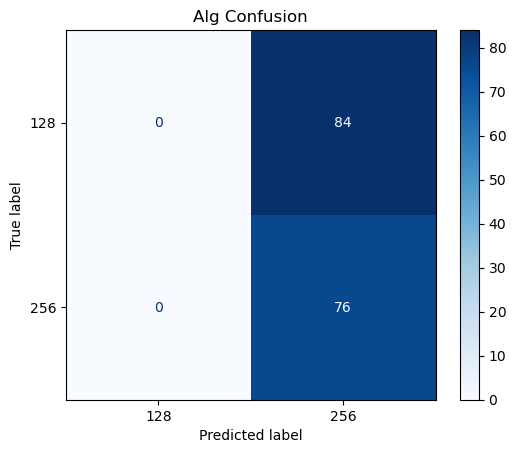

In [40]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=algs)
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=algs)
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()

In [34]:
pass_probs = pass_classifier.predict(test_data_format)
pass_preds = np.array([np.argmax(prob) for prob in pass_probs])
print(pass_preds)
print(enum_pass_test_targets)
pass_inv_mapping = {idx: label for label, idx in pass_mapping.items()}
pass_true_label = [pass_inv_mapping[idx] for idx in enum_pass_test_targets['password'].to_list()]
pass_pred_label = [pass_inv_mapping[idk] for idk in pass_preds]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3]
shape: (160, 4)
┌─────┬──────────┬─────────────────┬─────────────────────────────────┐
│ alg ┆ password ┆ source_file     ┆ plaintext                       │
│ --- ┆ ---      ┆ ---             ┆ ---                             │
│ str ┆ i64      ┆ str             ┆ binary                          │
╞═════╪══════════╪═════════════════╪═════════════════════════════════╡
│ 256 ┆ 3        ┆ Convo12Message2 ┆ b"Subject:\x20Kepler\x20-\x20N… │
│ 256 ┆ 0        ┆ Convo7Message0  ┆ b"Subject:\x20Nightingale\x20U… │
│ 128 ┆ 1        ┆ Convo1Message0  ┆ b"Subject:\x20Nightingale\x20U… │
│ 128 ┆ 2        ┆ Convo12Message4 ┆ b"Subject:\x20

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning: Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.
  warnings.warn(
/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning: Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.
  warnings.warn(


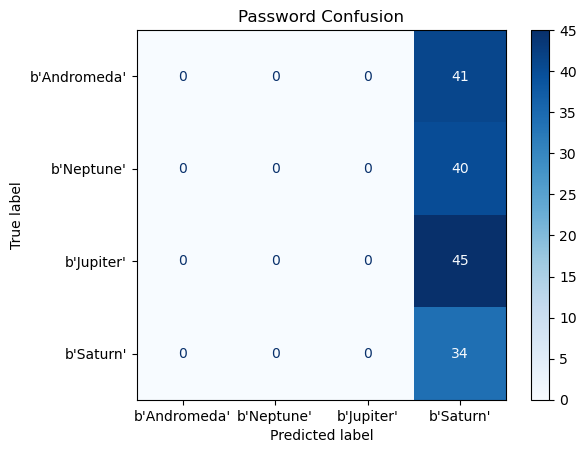

In [35]:
pass_confusion = confusion_matrix(pass_true_label, pass_pred_label, labels=passwords)
pass_disp = ConfusionMatrixDisplay(confusion_matrix=pass_confusion, display_labels=passwords)
pass_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Password Confusion")
plt.show()

In [73]:
encoded_data = encoder.predict(np.array(df['ciphertext'].to_list()))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [89]:
alg_true, alg_map = make_mapping(df, algs, 'alg')
print(encoded_data[:, 0])
print(len(encoded_data[:, 0]))
print(len(encoded_data[:, 1]))
print(len(encoded_data[:, 2]))
print(len(alg_true))
print(len(sc_alg_pred))
print(alg_true.shape)
print(sc_alg_pred.shape)
alg_true = alg_true['alg']
print(np.unique(sc_alg_pred, return_counts = True))

[3.9333255 1.8729178 6.1202917 ... 4.591957  3.0680947 4.89322  ]
1600
1600
1600
1600
1600
(1600, 5)
(1600,)
(array([0, 1], dtype=int32), array([1555,   45]))


In [85]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': alg_true,
    'Predicted Cluster': sc_alg_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Alg True Labels in Autoencoded 3D Space'
)
fig_true.show()

fig_pred = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='Predicted Cluster',
    title='Spectral Clustering in 3D Latent Space'
)
fig_pred.show()


In [90]:
pass_true, pass_map = make_mapping(df, passwords, 'password')
print(encoded_data[:, 0])
print(len(encoded_data[:, 0]))
print(len(encoded_data[:, 1]))
print(len(encoded_data[:, 2]))
print(len(alg_true))
print(len(sc_pass_pred))
print(pass_true.shape)
print(sc_pass_pred.shape)
pass_true = pass_true['password']
print(np.unique(sc_pass_pred, return_counts = True))

[3.9333255 1.8729178 6.1202917 ... 4.591957  3.0680947 4.89322  ]
1600
1600
1600
1600
1600
(1600, 5)
(1600,)
(array([0, 1, 2, 3], dtype=int32), array([1521,   33,   41,    5]))


In [91]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': pass_true,
    'Predicted Cluster': sc_pass_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Password True Labels in Autoencoded 3D Space'
)
fig_true.show()

fig_pred = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='Predicted Cluster',
    title='Spectral Clustering in 3D Latent Space'
)
fig_pred.show()


In [ ]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

In [ ]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=algs)
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=algs)
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()